In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df=pd.read_csv('dataset.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Temperature  90 non-null     int64 
 1   Humidity     90 non-null     int64 
 2   WindSpeed    90 non-null     int64 
 3   Pressure     90 non-null     int64 
 4   WeatherType  90 non-null     object
dtypes: int64(4), object(1)
memory usage: 3.6+ KB
None


In [3]:
df.head()

,Temperature,Humidity,WindSpeed,Pressure,WeatherType
0,32,40,8,1018,Sunny
1,30,45,10,1016,Sunny
2,34,35,6,1020,Sunny
3,31,42,9,1017,Sunny
4,33,38,7,1019,Sunny


In [4]:
df.tail()

,Temperature,Humidity,WindSpeed,Pressure,WeatherType
85,29,48,12,1014,Sunny
86,28,52,14,1013,Sunny
87,27,54,15,1012,Sunny
88,26,56,16,1011,Sunny
89,25,58,17,1010,Cloudy


In [5]:
print(df.describe())


       Temperature    Humidity  WindSpeed     Pressure
count    90.000000   90.000000  90.000000    90.000000
mean     24.133333   68.244444  25.255556  1005.855556
std       5.585294   21.408972  16.342239    10.163341
min      14.000000   32.000000   4.000000   982.000000
25%      20.000000   50.250000  12.250000   998.000000
50%      23.500000   67.000000  20.500000  1007.500000
75%      28.000000   88.750000  38.750000  1013.750000
max      35.000000  100.000000  65.000000  1023.000000


In [6]:
df.tail()

,Temperature,Humidity,WindSpeed,Pressure,WeatherType
85,29,48,12,1014,Sunny
86,28,52,14,1013,Sunny
87,27,54,15,1012,Sunny
88,26,56,16,1011,Sunny
89,25,58,17,1010,Cloudy


In [7]:
df.sample(5)

,Temperature,Humidity,WindSpeed,Pressure,WeatherType
6,35,33,5,1021,Sunny
20,24,75,20,1005,Rainy
35,20,90,42,997,Stormy
83,34,35,6,1021,Sunny
42,31,43,9,1017,Sunny


In [8]:
# check for missing value
print(df.isnull())

    Temperature  Humidity  WindSpeed  Pressure  WeatherType
0         False     False      False     False        False
1         False     False      False     False        False
2         False     False      False     False        False
3         False     False      False     False        False
4         False     False      False     False        False
..          ...       ...        ...       ...          ...
85        False     False      False     False        False
86        False     False      False     False        False
87        False     False      False     False        False
88        False     False      False     False        False
89        False     False      False     False        False

[90 rows x 5 columns]


In [9]:
counts=df["WeatherType"].value_counts()
print(counts)

WeatherType
Sunny     28
Cloudy    22
Rainy     20
Stormy    20
Name: count, dtype: int64


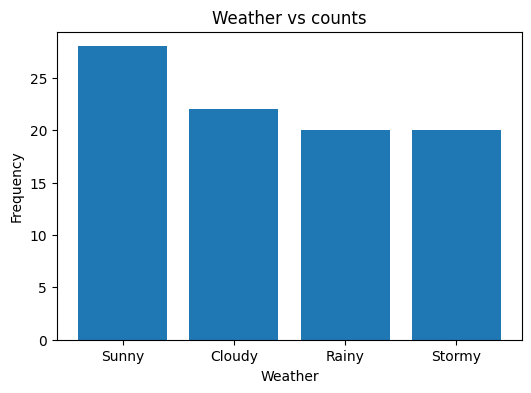

In [10]:
counts=df["WeatherType"].value_counts()
plt.figure(figsize=(6,4))
plt.bar(x=counts.index,height=counts.values)
plt.xlabel("Weather")
plt.ylabel("Frequency")
plt.title("Weather vs counts")
plt.savefig("Weather vs counts.svg",format="svg")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
#split the data set into x and y
X=df.drop(columns=['WeatherType'])
Y=df['WeatherType']
X_train, X_test , Y_train, Y_test=train_test_split(
    X,Y, test_size=0.2, random_state=42  #0.2 means 20% in test
)
print(f"Length of X_train and Y_train={X_train.shape}{Y_train.shape}")
print(f"Length of X_test and Y_test={X_test.shape}{Y_test.shape}")

Length of X_train and Y_train=(72, 4)(72,)
Length of X_test and Y_test=(18, 4)(18,)


In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

In [14]:
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,Y_train)
Y_preds=knn.predict(X_test)
print(f"Accuracy ={accuracy_score(Y_test,Y_preds)}")
print(f"Classification Report \n {classification_report(Y_test,Y_preds)}")

Accuracy =1.0
Classification Report 
               precision    recall  f1-score   support

      Cloudy       1.00      1.00      1.00         5
       Rainy       1.00      1.00      1.00         4
      Stormy       1.00      1.00      1.00         3
       Sunny       1.00      1.00      1.00         6

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



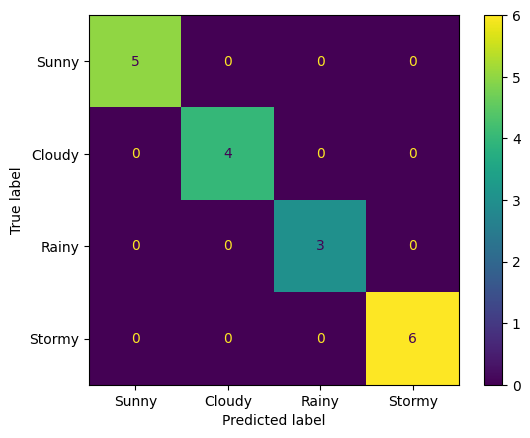

In [15]:
cm=confusion_matrix(Y_test,Y_preds)
cm_plot=ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=df['WeatherType'].unique()
)
cm_plot.plot()
plt.savefig('cm.png')
plt.savefig('cm.svg',format="svg")
plt.show()

In [16]:
import joblib
joblib.dump(knn,"knn_model.joblib")
print("SUCCESS")

SUCCESS
